In [6]:
import sys
from pathlib import Path

try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path.cwd()

project_root = _HERE.parents[0]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))



In [9]:
import numpy as np
import matplotlib.pyplot as plt

from dmrg1.dmrg_xxz import *
from dmrg1.run_xxz import *

In [10]:
# Compute magnetization in x, y, z directions across different phases of XXZhX Hamiltonian

# System parameters
L = 10  # System size (keep small for JAX compatibility)
chi_max = 5  # Bond dimension
max_sweep = 10  # Maximum number of DMRG sweeps
conf = 1e-5  # Convergence threshold

# Phase diagram parameters
# We'll scan delta (anisotropy) and h (transverse field) to explore different phases
delta_values = np.linspace(-2.0, 2.0, 20)  # Anisotropy: negative=XY-like, positive=Ising-like
h_values = np.linspace(0.5, 2.0, 20)  # Transverse field

# Storage for magnetizations
mag_x = np.zeros((len(delta_values), len(h_values)))
mag_y = np.zeros((len(delta_values), len(h_values)))
mag_z = np.zeros((len(delta_values), len(h_values)))
energies = np.zeros((len(delta_values), len(h_values)))

print(f"Running DMRG for {len(delta_values)} × {len(h_values)} = {len(delta_values)*len(h_values)} parameter points...")
print(f"System size L={L}, chi_max={chi_max}")
print()

# Helper function to compute local magnetization
def compute_magnetization(mps, L, pauli_char):
    """
    Compute average magnetization for a given Pauli operator
    pauli_char: '1' for X, '2' for Y, '3' for Z
    """
    mag_sum = 0.0
    for site in range(L):
        # Create Pauli string with identity everywhere except at 'site'
        pauli_string = '0' * site + pauli_char + '0' * (L - site - 1)
        pauli_mpo = Pauli_MPO(L=L, d=2, pauli_string=pauli_string)
        mag_sum += jnp.real(expect_mpo(mps, pauli_mpo))
    return mag_sum / L  # Average over all sites

# Main computation loop
for i, delta in enumerate(delta_values):
    for j, h in enumerate(h_values):
        # Run DMRG to get ground state
        mps, energy = dmrg_E(L, delta, h, conf=conf, test=False, chi_max=chi_max, max_sweep=max_sweep)
        
        # Compute magnetizations
        mag_x[i, j] = compute_magnetization(mps, L, '1')  # X magnetization
        mag_y[i, j] = compute_magnetization(mps, L, '2')  # Y magnetization
        mag_z[i, j] = compute_magnetization(mps, L, '3')  # Z magnetization
        energies[i, j] = energy
        
        # Progress indicator
        progress = (i * len(h_values) + j + 1) / (len(delta_values) * len(h_values)) * 100
        if (j + 1) % 5 == 0 or j == len(h_values) - 1:
            print(f"Progress: {progress:.1f}% | δ={delta:.2f}, h={h:.2f} | E={energy:.4f} | " + 
                  f"⟨Sx⟩={mag_x[i,j]:.4f}, ⟨Sy⟩={mag_y[i,j]:.4f}, ⟨Sz⟩={mag_z[i,j]:.4f}")

print("\nComputation complete!")


Running DMRG for 20 × 20 = 400 parameter points...
System size L=10, chi_max=5

Progress: 1.2% | δ=-2.00, h=0.82 | E=-18.7046 | ⟨Sx⟩=-0.1775, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9779
Progress: 2.5% | δ=-2.00, h=1.21 | E=-19.5595 | ⟨Sx⟩=-0.2696, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9468
Progress: 3.8% | δ=-2.00, h=1.61 | E=-20.7680 | ⟨Sx⟩=-0.3729, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.8902
Progress: 5.0% | δ=-2.00, h=2.00 | E=-22.3061 | ⟨Sx⟩=-0.4996, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.6073
Progress: 6.2% | δ=-1.79, h=0.82 | E=-16.8696 | ⟨Sx⟩=-0.1928, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9729
Progress: 7.5% | δ=-1.79, h=1.21 | E=-17.7931 | ⟨Sx⟩=-0.2988, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9293
Progress: 8.8% | δ=-1.79, h=1.61 | E=-19.0932 | ⟨Sx⟩=-0.4134, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.8388
Progress: 10.0% | δ=-1.79, h=2.00 | E=-20.8372 | ⟨Sx⟩=-0.5658, ⟨Sy⟩=0.0000, ⟨Sz⟩=-0.1457
Progress: 11.2% | δ=-1.58, h=0.82 | E=-15.0462 | ⟨Sx⟩=-0.2150, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9627
Progress: 12.5% | δ=-1.58, h=1.21 | E=-16.0518 | ⟨Sx⟩=-0.3349, ⟨Sy⟩=0.0000, ⟨Sz⟩=0.9022
Progress: 13.8% | δ=-1.58, h=1.61 | E=-17.3737

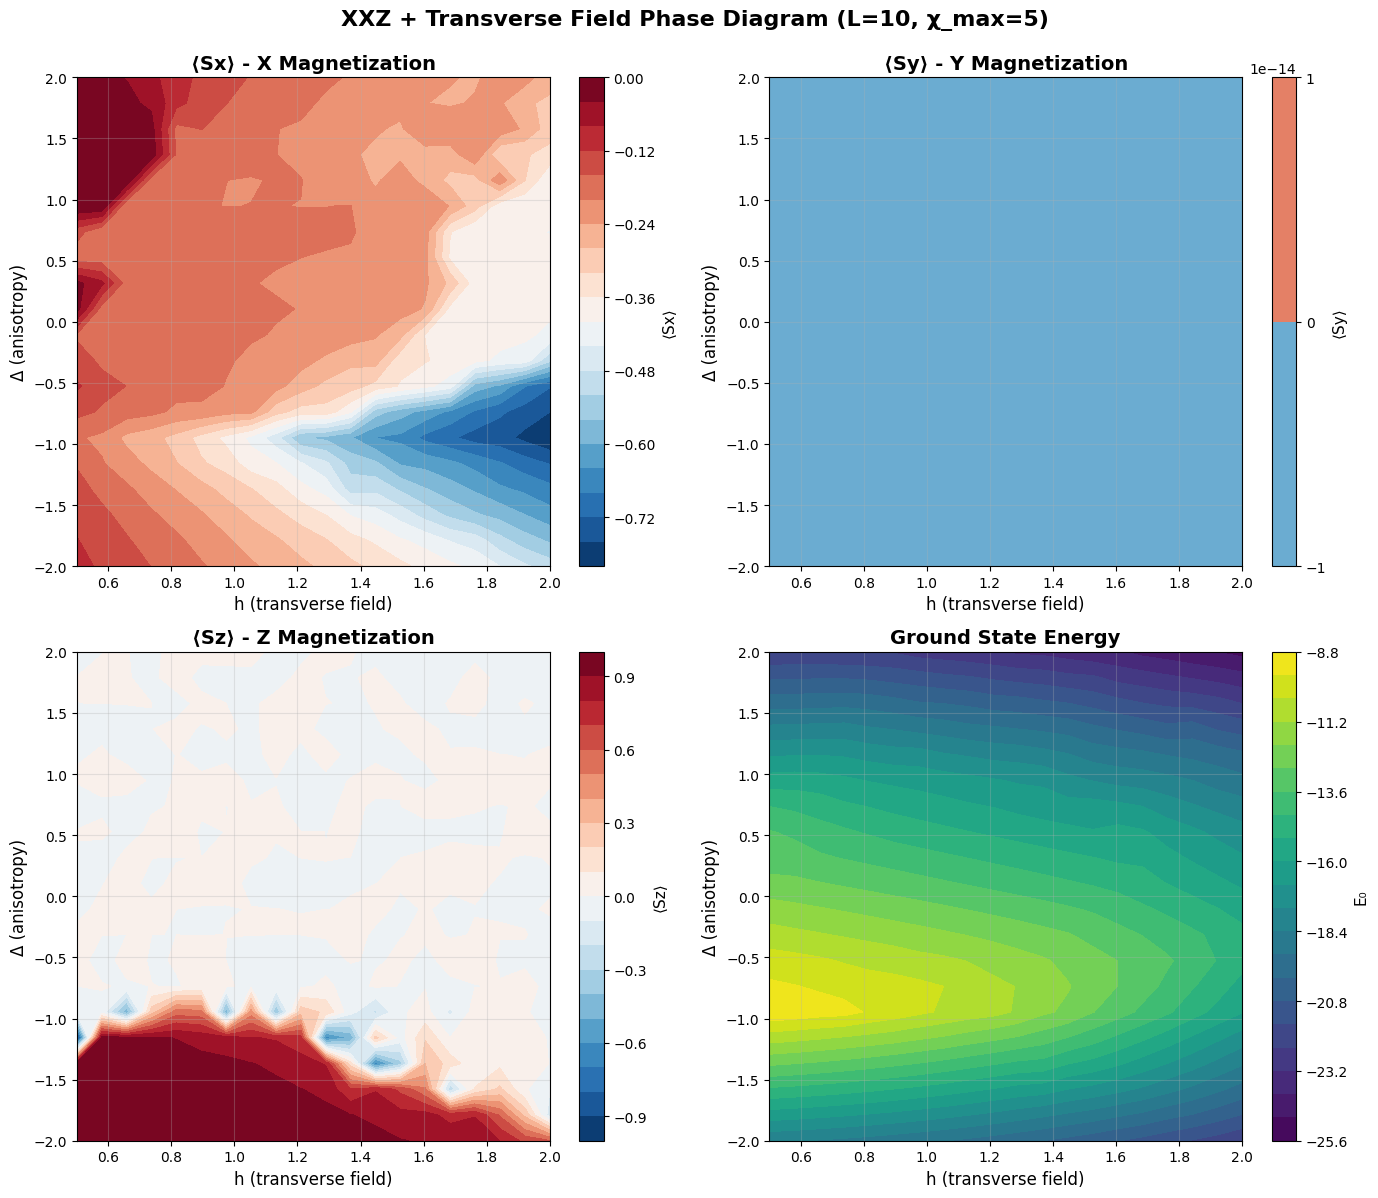


Phase diagram saved as 'xxzhx_magnetization_phase_diagram.pdf'


In [13]:
# Visualization of magnetization across phase diagram

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Create meshgrid for contour plots (H on x-axis, Delta on y-axis)
H, Delta = np.meshgrid(h_values, delta_values)

# Plot 1: X-magnetization
im1 = axes[0, 0].contourf(H, Delta, mag_x, levels=20, cmap='RdBu_r')
axes[0, 0].set_xlabel('h (transverse field)', fontsize=12)
axes[0, 0].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[0, 0].set_title('⟨Sx⟩ - X Magnetization', fontsize=14, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[0, 0])
cbar1.set_label('⟨Sx⟩', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Y-magnetization
im2 = axes[0, 1].contourf(H, Delta, mag_y, levels=20, cmap='RdBu_r')
axes[0, 1].set_xlabel('h (transverse field)', fontsize=12)
axes[0, 1].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[0, 1].set_title('⟨Sy⟩ - Y Magnetization', fontsize=14, fontweight='bold')
cbar2 = plt.colorbar(im2, ax=axes[0, 1])
cbar2.set_label('⟨Sy⟩', fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Z-magnetization
im3 = axes[1, 0].contourf(H, Delta, mag_z, levels=20, cmap='RdBu_r')
axes[1, 0].set_xlabel('h (transverse field)', fontsize=12)
axes[1, 0].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[1, 0].set_title('⟨Sz⟩ - Z Magnetization', fontsize=14, fontweight='bold')
cbar3 = plt.colorbar(im3, ax=axes[1, 0])
cbar3.set_label('⟨Sz⟩', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Ground state energy
im4 = axes[1, 1].contourf(H, Delta, energies, levels=20, cmap='viridis')
axes[1, 1].set_xlabel('h (transverse field)', fontsize=12)
axes[1, 1].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[1, 1].set_title('Ground State Energy', fontsize=14, fontweight='bold')
cbar4 = plt.colorbar(im4, ax=axes[1, 1])
cbar4.set_label('E₀', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'XXZ + Transverse Field Phase Diagram (L={L}, χ_max={chi_max})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('xxzhx_magnetization_phase_diagram.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nPhase diagram saved as 'xxzhx_magnetization_phase_diagram.pdf'")


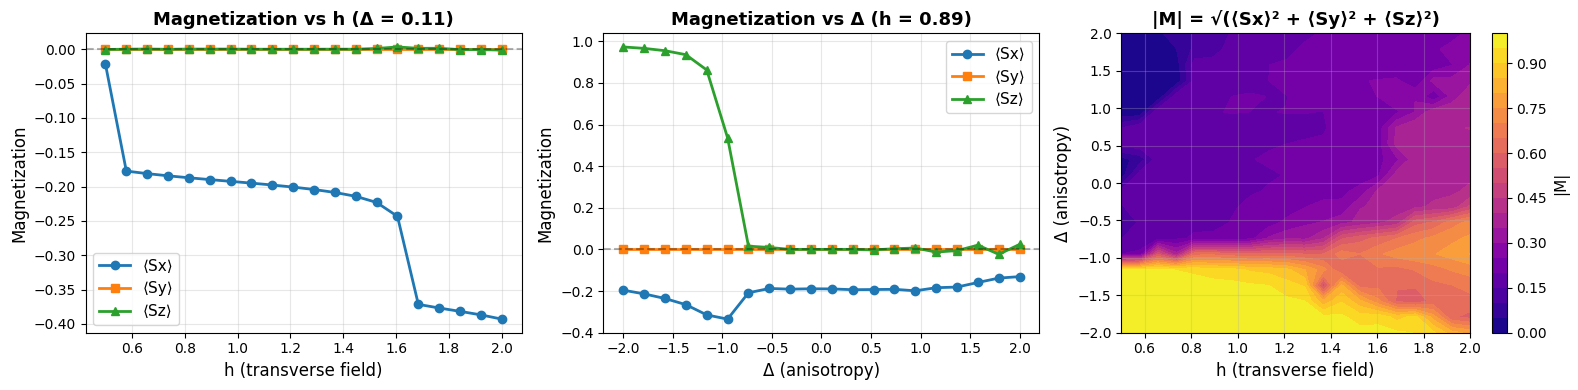

Line cuts saved as 'xxzhx_magnetization_linecuts.pdf'


In [14]:
# Additional analysis: Line cuts through phase diagram

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Line cut 1: Fixed delta, varying h
delta_fixed_idx = len(delta_values) // 2  # Middle value of delta
delta_fixed = delta_values[delta_fixed_idx]

axes[0].plot(h_values, mag_x[delta_fixed_idx, :], 'o-', label='⟨Sx⟩', linewidth=2, markersize=6)
axes[0].plot(h_values, mag_y[delta_fixed_idx, :], 's-', label='⟨Sy⟩', linewidth=2, markersize=6)
axes[0].plot(h_values, mag_z[delta_fixed_idx, :], '^-', label='⟨Sz⟩', linewidth=2, markersize=6)
axes[0].set_xlabel('h (transverse field)', fontsize=12)
axes[0].set_ylabel('Magnetization', fontsize=12)
axes[0].set_title(f'Magnetization vs h (Δ = {delta_fixed:.2f})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Line cut 2: Fixed h, varying delta
h_fixed_idx = len(h_values) // 4  # Low field
h_fixed = h_values[h_fixed_idx]

axes[1].plot(delta_values, mag_x[:, h_fixed_idx], 'o-', label='⟨Sx⟩', linewidth=2, markersize=6)
axes[1].plot(delta_values, mag_y[:, h_fixed_idx], 's-', label='⟨Sy⟩', linewidth=2, markersize=6)
axes[1].plot(delta_values, mag_z[:, h_fixed_idx], '^-', label='⟨Sz⟩', linewidth=2, markersize=6)
axes[1].set_xlabel('Δ (anisotropy)', fontsize=12)
axes[1].set_ylabel('Magnetization', fontsize=12)
axes[1].set_title(f'Magnetization vs Δ (h = {h_fixed:.2f})', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

# Total magnetization magnitude
mag_total = np.sqrt(mag_x**2 + mag_y**2 + mag_z**2)
H_mesh, Delta_mesh = np.meshgrid(h_values, delta_values)
im = axes[2].contourf(H_mesh, Delta_mesh, mag_total, levels=20, cmap='plasma')
axes[2].set_xlabel('h (transverse field)', fontsize=12)
axes[2].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[2].set_title('|M| = √(⟨Sx⟩² + ⟨Sy⟩² + ⟨Sz⟩²)', fontsize=13, fontweight='bold')
cbar = plt.colorbar(im, ax=axes[2])
cbar.set_label('|M|', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xxzhx_magnetization_linecuts.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Line cuts saved as 'xxzhx_magnetization_linecuts.pdf'")


## Summary of Results

This notebook computes the magnetization values in the x, y, and z directions for the **XXZ + transverse field Hamiltonian**:

$$H = \sum_i \left[ \sigma_i^x \sigma_{i+1}^x + \sigma_i^y \sigma_{i+1}^y + \Delta \sigma_i^z \sigma_{i+1}^z \right] + h \sum_i \sigma_i^x$$

### Expected Phases:

1. **Large Δ, small h**: Ising-like phase with Z-ordering (antiferromagnetic if Δ>0)
2. **Small Δ, small h**: XY-like phase with X-Y ordering  
3. **Large h**: Polarized phase along X-direction (transverse field dominant)
4. **Intermediate regions**: Competing orders and potential phase transitions

### Key Observables:

- **⟨Sx⟩**: X-magnetization (responds to transverse field)
- **⟨Sy⟩**: Y-magnetization (generally small due to discrete symmetry)
- **⟨Sz⟩**: Z-magnetization (responds to anisotropy Δ)
- **Ground state energy**: Indicates phase transitions via non-analyticities

The phase diagram maps out how these order parameters evolve across the (Δ, h) parameter space.


## Generate Training Dataset

Generate 1000 data points for autoencoder training with local Pauli measurements (Z, X, Y)


In [15]:
import pickle
from datetime import datetime

# Dataset generation parameters
L_data = 20  # System size for dataset
chi_max_data = 10  # Larger bond dimension for better accuracy
max_sweep_data = 15  # More sweeps for convergence
conf_data = 1e-6  # Tighter convergence
n_samples = 1000  # Number of data points

# Parameter ranges for dataset
delta_min, delta_max = -2.5, -1.5
h_min, h_max = 0.0, 0.5

print(f"Generating {n_samples} data points for training dataset")
print(f"L = {L_data}, chi_max = {chi_max_data}, max_sweep = {max_sweep_data}")
print(f"Delta range: [{delta_min}, {delta_max}]")
print(f"h range: [{h_min}, {h_max}]")
print()

# Initialize dataset
dataset = []

# Random sampling in parameter space
np.random.seed(42)
delta_samples = np.random.uniform(delta_min, delta_max, n_samples)
h_samples = np.random.uniform(h_min, h_max, n_samples)

# Helper function to compute all local Pauli observables
def compute_local_paulis(mps, L):
    """
    Compute local expectation values of Pauli X, Y, Z for all sites
    Returns: array of shape (3*L,) with ordering [Z0, Z1, ..., ZL-1, X0, X1, ..., XL-1, Y0, Y1, ..., YL-1]
    """
    obs = []
    
    # Pauli Z measurements for all sites
    for site in range(L):
        pauli_string = '0' * site + '3' + '0' * (L - site - 1)
        pauli_mpo = Pauli_MPO(L=L, d=2, pauli_string=pauli_string)
        obs.append(jnp.real(expect_mpo(mps, pauli_mpo)))
    
    # Pauli X measurements for all sites
    for site in range(L):
        pauli_string = '0' * site + '1' + '0' * (L - site - 1)
        pauli_mpo = Pauli_MPO(L=L, d=2, pauli_string=pauli_string)
        obs.append(jnp.real(expect_mpo(mps, pauli_mpo)))
    
    # Pauli Y measurements for all sites
    for site in range(L):
        pauli_string = '0' * site + '2' + '0' * (L - site - 1)
        pauli_mpo = Pauli_MPO(L=L, d=2, pauli_string=pauli_string)
        obs.append(jnp.real(expect_mpo(mps, pauli_mpo)))
    
    return jnp.array(obs)

# Generate dataset
print("Starting data generation...")
start_time = datetime.now()

for i, (delta, h) in enumerate(zip(delta_samples, h_samples)):
    # Run DMRG to get ground state
    mps, energy = dmrg_E(L_data, delta, h, 
                         conf=conf_data, 
                         test=False, 
                         chi_max=chi_max_data, 
                         max_sweep=max_sweep_data)
    
    # Compute local Pauli observables
    obs = compute_local_paulis(mps, L_data)
    
    # Store data point
    data_point = {
        'params': (float(delta), float(h)),
        'obs': np.array(obs)
    }
    dataset.append(data_point)
    
    # Progress update
    if (i + 1) % 50 == 0 or i == 0:
        elapsed = (datetime.now() - start_time).total_seconds()
        eta = elapsed / (i + 1) * (n_samples - i - 1)
        print(f"Progress: {i+1}/{n_samples} ({(i+1)/n_samples*100:.1f}%) | "
              f"δ={delta:.3f}, h={h:.3f} | E={energy:.4f} | "
              f"Elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s")

end_time = datetime.now()
total_time = (end_time - start_time).total_seconds()

print(f"\nDataset generation complete!")
print(f"Total time: {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Average time per sample: {total_time/n_samples:.2f}s")
print(f"Dataset size: {len(dataset)} samples")
print(f"Observable dimension per sample: {dataset[0]['obs'].shape}")

# Save dataset
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'../data/dmrg_data_xxz_dmrg1site_delta{delta_min}TO{delta_max}_h{h_min}TO{h_max}_L{L_data}_n{n_samples}_{timestamp}.pkl'
with open(filename, 'wb') as f:
    pickle.dump(dataset, f)

print(f"\nDataset saved to: {filename}")


Generating 1000 data points for training dataset
L = 20, chi_max = 10, max_sweep = 15
Delta range: [-2.5, -1.5]
h range: [0.0, 0.5]

Starting data generation...
Progress: 1/1000 (0.1%) | δ=-2.125, h=0.093 | E=-40.3992 | Elapsed: 6.1s | ETA: 6111.7s
Progress: 50/1000 (5.0%) | δ=-2.315, h=0.011 | E=-43.9880 | Elapsed: 100.5s | ETA: 1908.9s
Progress: 100/1000 (10.0%) | δ=-2.392, h=0.175 | E=-45.5009 | Elapsed: 194.7s | ETA: 1752.1s
Progress: 150/1000 (15.0%) | δ=-2.221, h=0.434 | E=-42.5356 | Elapsed: 285.7s | ETA: 1618.9s
Progress: 200/1000 (20.0%) | δ=-1.720, h=0.065 | E=-32.6912 | Elapsed: 373.9s | ETA: 1495.7s
Progress: 250/1000 (25.0%) | δ=-1.647, h=0.308 | E=-31.4985 | Elapsed: 474.0s | ETA: 1421.9s
Progress: 300/1000 (30.0%) | δ=-2.415, h=0.353 | E=-46.0843 | Elapsed: 567.5s | ETA: 1324.2s
Progress: 350/1000 (35.0%) | δ=-1.874, h=0.020 | E=-35.6095 | Elapsed: 661.6s | ETA: 1228.7s
Progress: 400/1000 (40.0%) | δ=-1.745, h=0.353 | E=-33.4233 | Elapsed: 748.7s | ETA: 1123.0s
Progress:

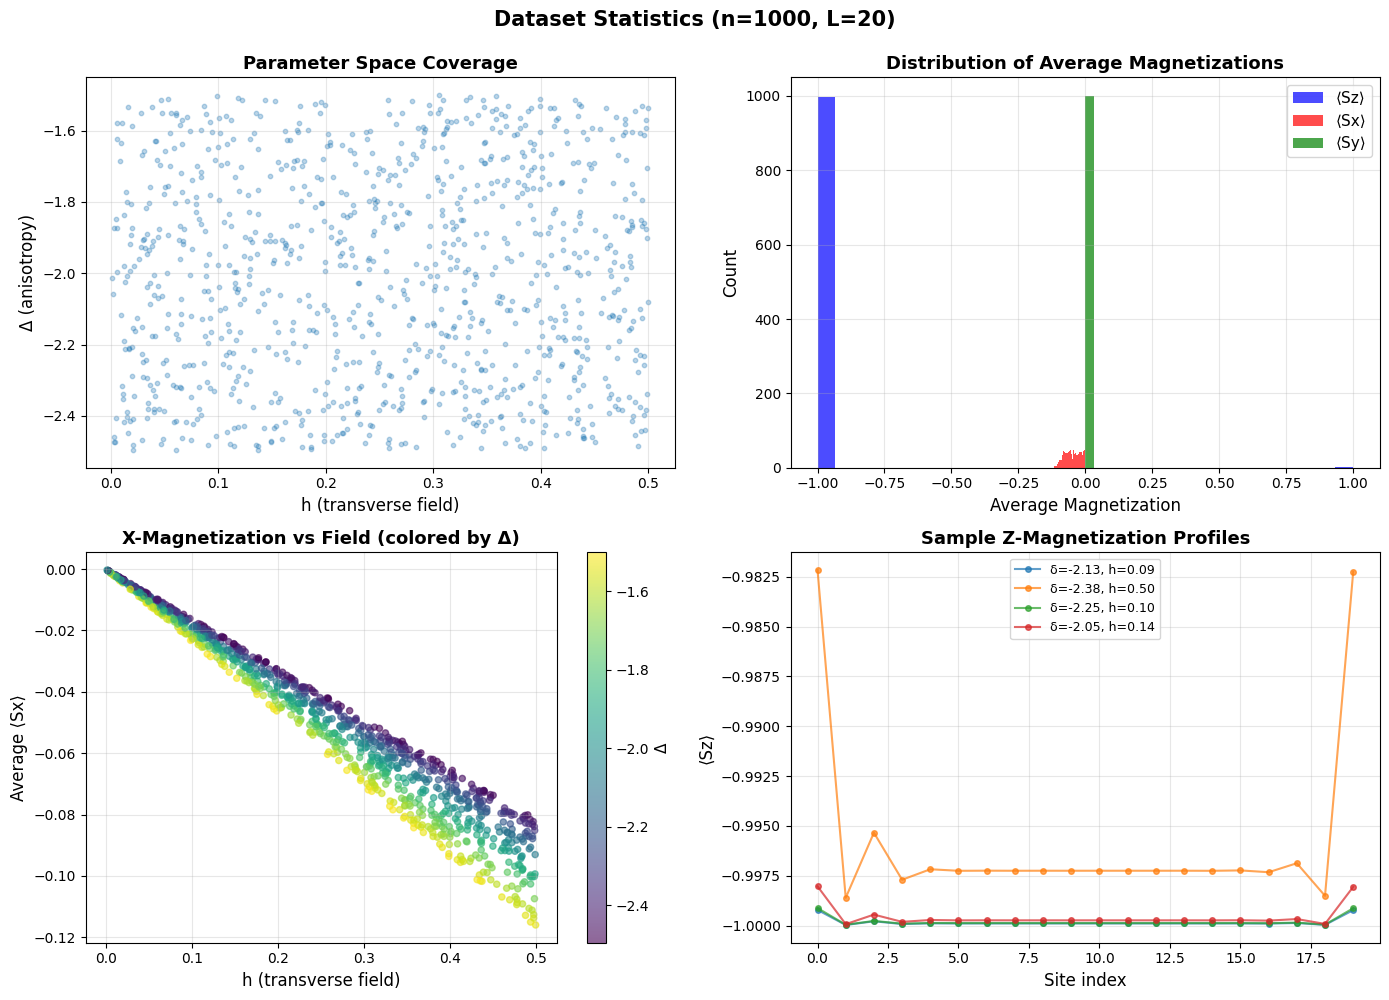

Dataset statistics visualization saved to '../figures/xxz_dmrg1site_dataset_statistics.pdf'


In [16]:
# Quick visualization of dataset statistics

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract parameters
deltas = np.array([d['params'][0] for d in dataset])
hs = np.array([d['params'][1] for d in dataset])
obs_array = np.array([d['obs'] for d in dataset])

# Plot 1: Parameter distribution
axes[0, 0].scatter(hs, deltas, alpha=0.3, s=10)
axes[0, 0].set_xlabel('h (transverse field)', fontsize=12)
axes[0, 0].set_ylabel('Δ (anisotropy)', fontsize=12)
axes[0, 0].set_title('Parameter Space Coverage', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Average magnetization distributions
avg_mz = np.mean(obs_array[:, :L_data], axis=1)  # Average Z magnetization
avg_mx = np.mean(obs_array[:, L_data:2*L_data], axis=1)  # Average X magnetization
avg_my = np.mean(obs_array[:, 2*L_data:], axis=1)  # Average Y magnetization

axes[0, 1].hist(avg_mz, bins=30, alpha=0.7, label='⟨Sz⟩', color='blue')
axes[0, 1].hist(avg_mx, bins=30, alpha=0.7, label='⟨Sx⟩', color='red')
axes[0, 1].hist(avg_my, bins=30, alpha=0.7, label='⟨Sy⟩', color='green')
axes[0, 1].set_xlabel('Average Magnetization', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('Distribution of Average Magnetizations', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Correlation between h and magnetization
sc = axes[1, 0].scatter(hs, avg_mx, c=deltas, cmap='viridis', alpha=0.6, s=20)
axes[1, 0].set_xlabel('h (transverse field)', fontsize=12)
axes[1, 0].set_ylabel('Average ⟨Sx⟩', fontsize=12)
axes[1, 0].set_title('X-Magnetization vs Field (colored by Δ)', fontsize=13, fontweight='bold')
cbar = plt.colorbar(sc, ax=axes[1, 0])
cbar.set_label('Δ', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Example observable profiles
sample_indices = [0, len(dataset)//3, 2*len(dataset)//3, len(dataset)-1]
for idx in sample_indices:
    delta_val, h_val = dataset[idx]['params']
    obs_z = dataset[idx]['obs'][:L_data]
    axes[1, 1].plot(range(L_data), obs_z, 'o-', alpha=0.7, 
                    label=f'δ={delta_val:.2f}, h={h_val:.2f}', markersize=4)

axes[1, 1].set_xlabel('Site index', fontsize=12)
axes[1, 1].set_ylabel('⟨Sz⟩', fontsize=12)
axes[1, 1].set_title('Sample Z-Magnetization Profiles', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Dataset Statistics (n={n_samples}, L={L_data})', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'../figures/xxz_dmrg1site_dataset_statistics.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Dataset statistics visualization saved to '../figures/xxz_dmrg1site_dataset_statistics.pdf'")
